In [1]:
import os
import sys
import zarr
import numpy as np
import pandas as pd
import xarray as xr
from glob import glob

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

## TC list

In [3]:
raw_cases = [
    # season, hurdat_id, storm, category, track_start, track_end
    (2020, "AL082020", "Hanna",    1, "2020-07-23 00:00", "2020-07-26 00:00"),
    (2020, "AL092020", "Isaias",   1, "2020-07-31 06:00", "2020-08-04 18:00"),
    (2020, "AL142020", "Marco",    1, "2020-08-22 12:00", "2020-08-25 00:00"),
    (2020, "AL132020", "Laura",    4, "2020-08-24 02:00", "2020-08-29 00:00"),
    (2020, "AL192020", "Sally",    2, "2020-09-11 18:00", "2020-09-17 06:00"),
    (2020, "AL252020", "Gamma",    1, "2020-10-03 16:45", "2020-10-06 12:00"),
    (2020, "AL262020", "Delta",    3, "2020-10-07 06:00", "2020-10-10 12:00"),
    (2020, "AL282020", "Zeta",     3, "2020-10-27 03:55", "2020-10-29 12:00"),
    (2020, "AL292020", "Eta",      1, "2020-11-08 00:00", "2020-11-13 06:00"),
    
    (2021, "AL052021", "Elsa",     1, "2021-07-05 00:00", "2021-07-09 16:30"),
    (2021, "AL082021", "Henri",    1, "2021-08-18 18:00", "2021-08-23 12:00"),
    (2021, "AL072021", "Grace",    3, "2021-08-19 09:45", "2021-08-21 12:00"),
    (2021, "AL092021", "Ida",      4, "2021-08-27 12:00", "2021-09-01 06:00"),
    (2021, "AL142021", "Nicholas", 1, "2021-09-12 12:00", "2021-09-15 12:00"),
    
    (2022, "AL072022", "Fiona",    4, "2022-09-20 00:00", "2022-09-23 06:00"),
    (2022, "AL092022", "Ian",      5, "2022-09-27 00:00", "2022-09-30 18:05"),
    (2022, "AL172022", "Nicole",   1, "2022-11-07 06:00", "2022-11-11 12:00"),
    
    (2023, "AL082023", "Franklin", 4, "2023-08-24 00:00", "2023-08-30 12:00"),
    (2023, "AL102023", "Idalia",   4, "2023-08-26 12:00", "2023-08-31 06:00"),
    (2023, "AL132023", "Lee",      2, "2023-09-13 12:00", "2023-09-15 12:00"),
    
    (2024, "AL022024", "Beryl",    1, "2024-07-05 11:00", "2024-07-09 06:00"),
    (2024, "AL042024", "Debby",    1, "2024-08-03 00:00", "2024-08-08 18:00"),
    (2024, "AL052024", "Ernesto",  2, "2024-08-14 18:00", "2024-08-16 06:00"),
    (2024, "AL062024", "Francine",  2, "2024-09-09 12:00", "2024-09-12 12:00"),
    (2024, "AL092024", "Helene",   4, "2024-09-25 06:00", "2024-09-27 12:00"),
]

### Ian 2022

In [7]:
year = 2022
T0 = '2022-09-27T00'
T1 = '2022-09-30T18'

fn_target = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/C404_8km/C404_8km_{year}.zarr'
ds_target = xr.open_zarr(fn_target).sel(time=slice(T0, T1))
ds_target['WRF_PWAT'] = ds_target['WRF_PWAT_05']**2
ds_target['WRF_Q_tot'] = ds_target['WRF_Q_tot_05']**2
ds_target['WRF_precip'] = ds_target['WRF_precip_025']**4
ds_target = ds_target.drop_vars(('WRF_PWAT_05', 'WRF_precip_025', 'WRF_Q_tot_05',))

fn_ERA5 = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred/pred_ERA5_{year}.zarr'
ds_ERA5 = xr.open_zarr(fn_ERA5).sel(time=slice(T0, T1))
ds_ERA5['WRF_PWAT'] = ds_ERA5['WRF_PWAT_05']**2
ds_ERA5['WRF_Q_tot'] = ds_ERA5['WRF_Q_tot_05']**2
ds_ERA5['WRF_precip'] = ds_ERA5['WRF_precip_025']**4

# ERA5-based corrdiff
fn_era5 = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred_corrdiff_final/TC_ERA5_corrdiff_pred_{year}_mem*.zarr'
list_fn_era5 = sorted(glob(fn_era5))

list_ds_era5 = []
for fn_ in list_fn_era5:
    list_ds_era5.append(xr.open_zarr(fn_).sel(time=slice(T0, T1)))
ds_ERA5_corrdiff = xr.concat(list_ds_era5, dim='member')

fn_GDAS = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred/pred_GDAS_{year}.zarr'
ds_GDAS = xr.open_zarr(fn_GDAS).sel(time=slice(T0, T1))
ds_GDAS['WRF_PWAT'] = ds_GDAS['WRF_PWAT_05']**2
ds_GDAS['WRF_Q_tot'] = ds_GDAS['WRF_Q_tot_05']**2
ds_GDAS['WRF_precip'] = ds_GDAS['WRF_precip_025']**4

# GDAS-based corrdiff
fn_GDAS = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred_corrdiff_final/TC_GDAS_corrdiff_pred_{year}_mem*.zarr'
list_fn_GDAS = sorted(glob(fn_GDAS))

list_ds_GDAS = []
for fn_ in list_fn_GDAS:
    list_ds_GDAS.append(xr.open_zarr(fn_).sel(time=slice(T0, T1)))
ds_GDAS_corrdiff = xr.concat(list_ds_GDAS, dim='member')

# SAVE ds_target, ds_ERA5, ds_ERA5_corrdiff, ds_GDAS, ds_GDAS_corrdiff as netcdf4
save_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_cases/EXAMPLE/Ian_2022_case_fig.nc'

os.makedirs(os.path.dirname(save_name), exist_ok=True)
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_target.data_vars}
ds_target.to_netcdf(save_name, group='target',  mode='a', engine='netcdf4' )
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_ERA5.data_vars}
ds_ERA5.to_netcdf(save_name, group='ERA5', mode='a', engine='netcdf4' )
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_ERA5_corrdiff.data_vars}
ds_ERA5_corrdiff.to_netcdf(save_name, group='ERA5_corrdiff', mode='a', engine='netcdf4' )
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_GDAS.data_vars}
ds_GDAS.to_netcdf(save_name, group='GDAS', mode='a', engine='netcdf4' )
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_GDAS_corrdiff.data_vars}
ds_GDAS_corrdiff.to_netcdf(save_name, group='GDAS_corrdiff', mode='a', engine='netcdf4' )
print(save_name)

/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_cases/EXAMPLE/Ian_2022_case_fig.nc


In [8]:
ds_target        = xr.open_dataset(save_name, group='target')
ds_ERA5          = xr.open_dataset(save_name, group='ERA5')
ds_ERA5_corrdiff = xr.open_dataset(save_name, group='ERA5_corrdiff')
ds_GDAS          = xr.open_dataset(save_name, group='GDAS')
ds_GDAS_corrdiff = xr.open_dataset(save_name, group='GDAS_corrdiff')

In [9]:
year = 2020
T0 = "2020-08-24T02"
T1 = "2020-08-29T00"

fn_target = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/C404_8km/C404_8km_{year}.zarr'
ds_target = xr.open_zarr(fn_target).sel(time=slice(T0, T1))
ds_target['WRF_PWAT'] = ds_target['WRF_PWAT_05']**2
ds_target['WRF_Q_tot'] = ds_target['WRF_Q_tot_05']**2
ds_target['WRF_precip'] = ds_target['WRF_precip_025']**4
ds_target = ds_target.drop_vars(('WRF_PWAT_05', 'WRF_precip_025', 'WRF_Q_tot_05',))

fn_ERA5 = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred/pred_ERA5_{year}.zarr'
ds_ERA5 = xr.open_zarr(fn_ERA5).sel(time=slice(T0, T1))
ds_ERA5['WRF_PWAT'] = ds_ERA5['WRF_PWAT_05']**2
ds_ERA5['WRF_Q_tot'] = ds_ERA5['WRF_Q_tot_05']**2
ds_ERA5['WRF_precip'] = ds_ERA5['WRF_precip_025']**4

# ERA5-based corrdiff
fn_era5 = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred_corrdiff_final/TC_ERA5_corrdiff_pred_{year}_mem*.zarr'
list_fn_era5 = sorted(glob(fn_era5))

list_ds_era5 = []
for fn_ in list_fn_era5:
    list_ds_era5.append(xr.open_zarr(fn_).sel(time=slice(T0, T1)))
ds_ERA5_corrdiff = xr.concat(list_ds_era5, dim='member')

fn_GDAS = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred/pred_GDAS_{year}.zarr'
ds_GDAS = xr.open_zarr(fn_GDAS).sel(time=slice(T0, T1))
ds_GDAS['WRF_PWAT'] = ds_GDAS['WRF_PWAT_05']**2
ds_GDAS['WRF_Q_tot'] = ds_GDAS['WRF_Q_tot_05']**2
ds_GDAS['WRF_precip'] = ds_GDAS['WRF_precip_025']**4

# GDAS-based corrdiff
fn_GDAS = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred_corrdiff_final/TC_GDAS_corrdiff_pred_{year}_mem*.zarr'
list_fn_GDAS = sorted(glob(fn_GDAS))

list_ds_GDAS = []
for fn_ in list_fn_GDAS:
    list_ds_GDAS.append(xr.open_zarr(fn_).sel(time=slice(T0, T1)))
ds_GDAS_corrdiff = xr.concat(list_ds_GDAS, dim='member')

# SAVE ds_target, ds_ERA5, ds_ERA5_corrdiff, ds_GDAS, ds_GDAS_corrdiff as netcdf4
save_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_cases/EXAMPLE/Laura_2020_case_fig.nc'
os.makedirs(os.path.dirname(save_name), exist_ok=True)
# enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_target.data_vars}
ds_target.to_netcdf(save_name, group='target',  mode='a', engine='netcdf4' )
# enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_ERA5.data_vars}
ds_ERA5.to_netcdf(save_name, group='ERA5', mode='a', engine='netcdf4' )
# enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_ERA5_corrdiff.data_vars}
ds_ERA5_corrdiff.to_netcdf(save_name, group='ERA5_corrdiff', mode='a', engine='netcdf4' )
# enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_GDAS.data_vars}
ds_GDAS.to_netcdf(save_name, group='GDAS', mode='a', engine='netcdf4' )
# enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_GDAS_corrdiff.data_vars}
ds_GDAS_corrdiff.to_netcdf(save_name, group='GDAS_corrdiff',  mode='a', engine='netcdf4')
print(save_name)

/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_cases/EXAMPLE/Laura_2020_case_fig.nc


In [10]:
year = 2024
T0 = "2024-09-25T06"
T1 = "2024-09-27T12"

fn_target = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/C404_8km/C404_8km_{year}.zarr'
ds_target = xr.open_zarr(fn_target).sel(time=slice(T0, T1))
ds_target['WRF_PWAT'] = ds_target['WRF_PWAT_05']**2
ds_target['WRF_Q_tot'] = ds_target['WRF_Q_tot_05']**2
ds_target['WRF_precip'] = ds_target['WRF_precip_025']**4
ds_target = ds_target.drop_vars(('WRF_PWAT_05', 'WRF_precip_025', 'WRF_Q_tot_05',))

fn_ERA5 = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred/pred_ERA5_{year}.zarr'
ds_ERA5 = xr.open_zarr(fn_ERA5).sel(time=slice(T0, T1))
ds_ERA5['WRF_PWAT'] = ds_ERA5['WRF_PWAT_05']**2
ds_ERA5['WRF_Q_tot'] = ds_ERA5['WRF_Q_tot_05']**2
ds_ERA5['WRF_precip'] = ds_ERA5['WRF_precip_025']**4

# ERA5-based corrdiff
fn_era5 = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred_corrdiff_final/TC_ERA5_corrdiff_pred_{year}_mem*.zarr'
list_fn_era5 = sorted(glob(fn_era5))

list_ds_era5 = []
for fn_ in list_fn_era5:
    list_ds_era5.append(xr.open_zarr(fn_).sel(time=slice(T0, T1)))
ds_ERA5_corrdiff = xr.concat(list_ds_era5, dim='member')

fn_GDAS = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred/pred_GDAS_{year}.zarr'
ds_GDAS = xr.open_zarr(fn_GDAS).sel(time=slice(T0, T1))
ds_GDAS['WRF_PWAT'] = ds_GDAS['WRF_PWAT_05']**2
ds_GDAS['WRF_Q_tot'] = ds_GDAS['WRF_Q_tot_05']**2
ds_GDAS['WRF_precip'] = ds_GDAS['WRF_precip_025']**4

# GDAS-based corrdiff
fn_GDAS = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_pred_corrdiff_final/TC_GDAS_corrdiff_pred_{year}_mem*.zarr'
list_fn_GDAS = sorted(glob(fn_GDAS))

list_ds_GDAS = []
for fn_ in list_fn_GDAS:
    list_ds_GDAS.append(xr.open_zarr(fn_).sel(time=slice(T0, T1)))
ds_GDAS_corrdiff = xr.concat(list_ds_GDAS, dim='member')

# SAVE ds_target, ds_ERA5, ds_ERA5_corrdiff, ds_GDAS, ds_GDAS_corrdiff as netcdf4
save_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_cases/EXAMPLE/Helene_2024_case_fig.nc'
os.makedirs(os.path.dirname(save_name), exist_ok=True)
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_target.data_vars}
ds_target.to_netcdf(save_name, group='target',  mode='a', engine='netcdf4' )
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_ERA5.data_vars}
ds_ERA5.to_netcdf(save_name, group='ERA5', mode='a', engine='netcdf4' )
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_ERA5_corrdiff.data_vars}
ds_ERA5_corrdiff.to_netcdf(save_name, group='ERA5_corrdiff', mode='a', engine='netcdf4' )
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_GDAS.data_vars}
ds_GDAS.to_netcdf(save_name, group='GDAS', mode='a', engine='netcdf4' )
#enc = {v: {'zlib': True, 'complevel': 1, 'shuffle': True} for v in ds_GDAS_corrdiff.data_vars}
ds_GDAS_corrdiff.to_netcdf(save_name, group='GDAS_corrdiff',  mode='a', engine='netcdf4' )
print(save_name)

/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_cases/EXAMPLE/Helene_2024_case_fig.nc


### Check Ian

In [3]:
save_name = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/TC_cases/EXAMPLE/Ian_2022_case_fig.nc'

ds_target        = xr.open_dataset(save_name, group='target')
ds_ERA5          = xr.open_dataset(save_name, group='ERA5')
ds_ERA5_corrdiff = xr.open_dataset(save_name, group='ERA5_corrdiff')
ds_GDAS          = xr.open_dataset(save_name, group='GDAS')
ds_GDAS_corrdiff = xr.open_dataset(save_name, group='GDAS_corrdiff')

In [14]:
i_time = 40
u10 = ds_ERA5_corrdiff['WRF_U10'].isel(member=0, time=i_time).values
v10 = ds_ERA5_corrdiff['WRF_V10'].isel(member=0, time=i_time).values

u10_target = ds_target['WRF_U10'].isel(time=i_time).values
v10_target = ds_target['WRF_V10'].isel(time=i_time).values

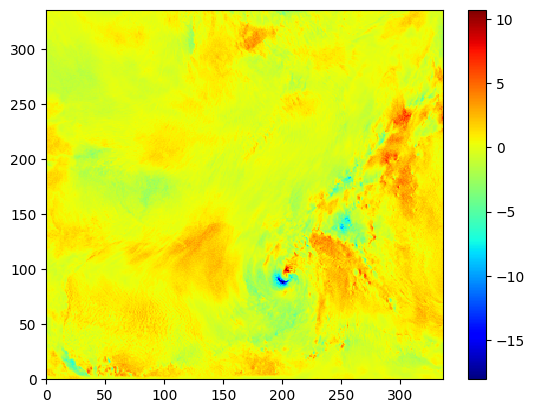

In [16]:
plt.pcolormesh(u10-u10_target, cmap=plt.cm.jet)
plt.colorbar()

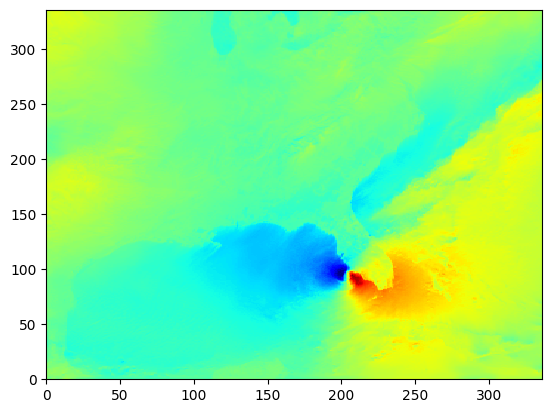

In [13]:
plt.pcolormesh(v10, cmap=plt.cm.jet)